In [5]:
from functions import fingerprint
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

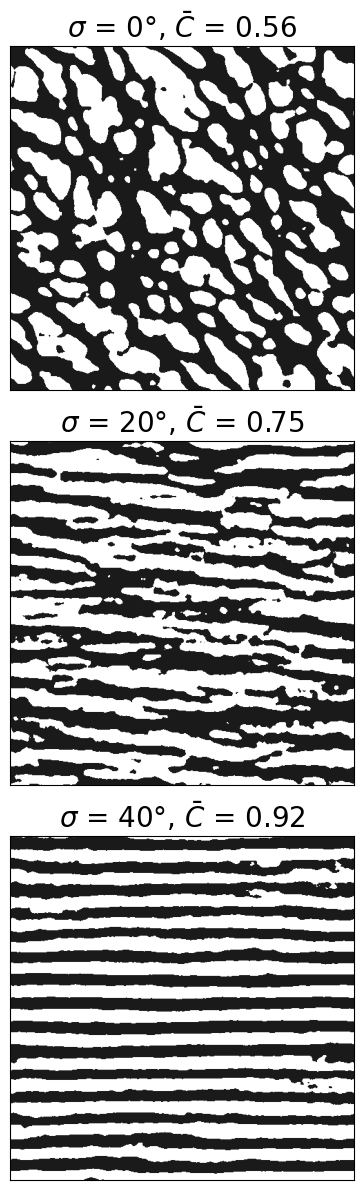

In [17]:

repeats = 10
# list numN largest to smallest! 
numN = np.array([3, 3, 3])
# order doesn't matter for slope
slopes = np.array([0, 20, 40])
# particular repeats to plot
repeats = np.array([3, 9, 7])

resolution = 10
max_erosion = 2*resolution

fig, axs = plt.subplots(nrows = 3, figsize=(4, 12)) 

for i, ax in enumerate(axs): 
    
    elevation_map = np.load(f'fig06/maps/elevation_map_{slopes[i]}.npy') 
    trampled = np.load(f'fig06/maps/trampled_{slopes[i]}_{50}_{numN[i]}_{repeats[i]}.npy')
    total_erosion = trampled-elevation_map
    total_erosion = -(total_erosion - np.max(total_erosion))

    omega = 20
    theta, mean_gradient, mean_coherence = fingerprint(total_erosion, omega, ground_truth=None, plot=False)

                    #total_erosion = - total_erosio
    threshold = np.mean(total_erosion)
    total_erosion[total_erosion >= threshold] = max_erosion
    total_erosion[total_erosion < threshold] = 0
    ax.imshow(total_erosion, origin='lower', cmap='Greys', vmin=0, vmax=max_erosion+2)
    ax.set_xticks([])
    ax.set_yticks([])

    coherence = mean_coherence 
    ax.set_title(f'$\sigma$ = {slopes[i]}°, ' + r'$\bar{C}$' + f' = {coherence:.2f}', c='k', fontsize=20, fontweight=400)
        
plt.tight_layout()
plt.show()
